# DA6401 W&B Notebook 



In [7]:
import wandb
import numpy as np
import matplotlib.pyplot as plt
import subprocess
from tensorflow.keras.datasets import mnist, fashion_mnist

PROJECT = 'da6401_mlp'
ENTITY = 'anan-madhav-iit-madras'

## Dataset Visualization

In [8]:
wandb.init(project=PROJECT, name='mnist_dataset_visualization')

(X_train, y_train), _ = mnist.load_data()

table = wandb.Table(columns=['image','label'])

for digit in range(10):
    idx = np.where(y_train == digit)[0][:5]
    for i in idx:
        table.add_data(wandb.Image(X_train[i]), digit)

wandb.log({'mnist_samples': table})
wandb.finish()

## Sweep Analysis Using Existing Runs

In [18]:
api = wandb.Api()

runs = api.runs(f"{ENTITY}/{PROJECT}")

optimizers = []
val_acc = []
test_acc = []

for run in runs:

    opt = run.config.get("optimizer")
    v = run.summary.get("val_accuracy")
    t = run.summary.get("test_accuracy")

    if opt is not None and v is not None:

        optimizers.append(opt)
        val_acc.append(v)

        if t is not None:
            test_acc.append(t)
        else:
            test_acc.append(0)

print("Total runs analyzed:", len(val_acc))

Total runs analyzed: 226


### Optimizer Impact Plot

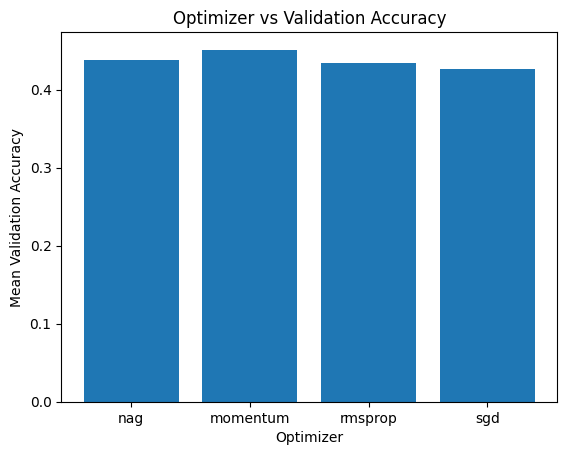

In [19]:
unique_opts = list(set(optimizers))
means = []

for opt in unique_opts:

    values = []

    for i in range(len(optimizers)):
        if optimizers[i] == opt:
            values.append(val_acc[i])

    if len(values) > 0:
        means.append(np.mean(values))
    else:
        means.append(0)


plt.bar(unique_opts, means)
plt.xlabel("Optimizer")
plt.ylabel("Mean Validation Accuracy")
plt.title("Optimizer vs Validation Accuracy")
plt.show()

## Optimizer Comparison Experiments 

In [21]:
optimizers = ['sgd', 'momentum', 'nag', 'rmsprop']

for opt in optimizers:

    cmd = [
        'python', '../src/train.py',
        '--dataset', 'mnist',
        '--epochs', '5',
        '--batch_size', '64',
        '--optimizer', opt,
        '--learning_rate', '0.001',
        '--activation', 'relu',
        '--hidden_size', '128', '128', '128',
        '--wandb_project', PROJECT,
        '--model_save_path', 'temp_model'
    ]

    subprocess.run(cmd)

I0000 00:00:1772976862.652103  876707 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772976862.653096  876707 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772976862.806839  876707 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772976864.832457  876707 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 2.3306 - Val Accuracy: 0.0798
Epoch 2/5 - Loss: 2.3277 - Val Accuracy: 0.0842
Epoch 3/5 - Loss: 2.3248 - Val Accuracy: 0.0867
Epoch 4/5 - Loss: 2.3220 - Val Accuracy: 0.0895
Epoch 5/5 - Loss: 2.3193 - Val Accuracy: 0.0933
Evaluating model...
Test Accuracy: 0.0952
Saving model...
Training complete.


I0000 00:00:1772976909.169481  876966 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772976909.170747  876966 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772976909.298090  876966 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772976911.294806  876966 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 2.3194 - Val Accuracy: 0.0958
Epoch 2/5 - Loss: 2.3153 - Val Accuracy: 0.1032
Epoch 3/5 - Loss: 2.3112 - Val Accuracy: 0.1082
Epoch 4/5 - Loss: 2.3073 - Val Accuracy: 0.1143
Epoch 5/5 - Loss: 2.3034 - Val Accuracy: 0.1203
Evaluating model...
Test Accuracy: 0.1207
Saving model...
Training complete.


I0000 00:00:1772976996.535338  877257 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772976996.537036  877257 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772976996.729615  877257 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772976999.760475  877257 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 2.3147 - Val Accuracy: 0.1087
Epoch 2/5 - Loss: 2.3120 - Val Accuracy: 0.1122
Epoch 3/5 - Loss: 2.3093 - Val Accuracy: 0.1145
Epoch 4/5 - Loss: 2.3066 - Val Accuracy: 0.1203
Epoch 5/5 - Loss: 2.3040 - Val Accuracy: 0.1247
Evaluating model...
Test Accuracy: 0.1281
Saving model...
Training complete.


I0000 00:00:1772977104.518754  877611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772977104.520079  877611 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772977104.675607  877611 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772977107.752559  877611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 2.3435 - Val Accuracy: 0.0963
Epoch 2/5 - Loss: 2.3390 - Val Accuracy: 0.0975
Epoch 3/5 - Loss: 2.3346 - Val Accuracy: 0.1010
Epoch 4/5 - Loss: 2.3302 - Val Accuracy: 0.1030
Epoch 5/5 - Loss: 2.3259 - Val Accuracy: 0.1048
Evaluating model...
Test Accuracy: 0.1089
Saving model...
Training complete.


## Vanishing Gradient Experiments

In [23]:
for act in ['sigmoid', 'relu']:

    cmd = [
        'python', '../src/train.py',
        '--dataset', 'mnist',
        '--epochs', '5',
        '--optimizer', 'rmsprop',
        '--learning_rate', '0.001',
        '--activation', act,
        '--hidden_size', '128', '128', '128',
        '--wandb_project', PROJECT,
        '--model_save_path', 'temp_model'
    ]

    subprocess.run(cmd)

I0000 00:00:1772977488.448693  878867 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772977488.449483  878867 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772977488.535222  878867 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772977490.493073  878867 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 2.4882 - Val Accuracy: 0.1013
Epoch 2/5 - Loss: 2.4125 - Val Accuracy: 0.1013
Epoch 3/5 - Loss: 2.3707 - Val Accuracy: 0.1013
Epoch 4/5 - Loss: 2.3461 - Val Accuracy: 0.1013
Epoch 5/5 - Loss: 2.3310 - Val Accuracy: 0.1013
Evaluating model...
Test Accuracy: 0.101
Saving model...
Training complete.


I0000 00:00:1772977578.598387  879145 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772977578.599717  879145 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772977578.698746  879145 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772977580.736631  879145 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 2.3254 - Val Accuracy: 0.1072
Epoch 2/5 - Loss: 2.3083 - Val Accuracy: 0.1165
Epoch 3/5 - Loss: 2.2920 - Val Accuracy: 0.1250
Epoch 4/5 - Loss: 2.2762 - Val Accuracy: 0.1342
Epoch 5/5 - Loss: 2.2608 - Val Accuracy: 0.1493
Evaluating model...
Test Accuracy: 0.1599
Saving model...
Training complete.


## Dead Neuron Investigation

In [25]:
for act in ['relu','tanh']:

    cmd = [
        'python','../src/train.py',
        '--dataset','mnist',
        '--epochs','5',
        '--optimizer','sgd',
        '--learning_rate','0.1',
        '--activation',act,
        '--hidden_size','128','128',
        '--wandb_project',PROJECT,
        '--model_save_path','temp_model'
    ]

    subprocess.run(cmd)

I0000 00:00:1772978706.201584  882676 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772978706.202205  882676 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772978706.259004  882676 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772978708.404691  882676 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 1.1594 - Val Accuracy: 0.8592
Epoch 2/5 - Loss: 0.4718 - Val Accuracy: 0.8932
Epoch 3/5 - Loss: 0.3774 - Val Accuracy: 0.9058
Epoch 4/5 - Loss: 0.3357 - Val Accuracy: 0.9152
Epoch 5/5 - Loss: 0.3084 - Val Accuracy: 0.9217
Evaluating model...
Test Accuracy: 0.9192
Saving model...
Training complete.


I0000 00:00:1772978738.048836  882800 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772978738.049900  882800 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772978738.114559  882800 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772978739.306267  882800 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 0.9627 - Val Accuracy: 0.8640
Epoch 2/5 - Loss: 0.4785 - Val Accuracy: 0.8962
Epoch 3/5 - Loss: 0.3955 - Val Accuracy: 0.9075
Epoch 4/5 - Loss: 0.3568 - Val Accuracy: 0.9117
Epoch 5/5 - Loss: 0.3330 - Val Accuracy: 0.9170
Evaluating model...
Test Accuracy: 0.9137
Saving model...
Training complete.


## Loss Function Comparison

In [30]:
for loss in ['mse','cross_entropy']:

    cmd = [
        'python','../src/train.py',
        '--dataset','mnist',
        '--epochs','5',
        '--optimizer','rmsprop',
        '--learning_rate','0.001',
        '--activation','relu',
        '--hidden_size','128','64',
        '--loss',loss,
        '--wandb_project',PROJECT,
        '--model_save_path','temp_model'
    ]

    subprocess.run(cmd)

I0000 00:00:1772979216.721407  884740 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772979216.721972  884740 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772979216.776170  884740 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772979218.176314  884740 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 0.1396 - Val Accuracy: 0.1615
Epoch 2/5 - Loss: 0.1072 - Val Accuracy: 0.2212
Epoch 3/5 - Loss: 0.0982 - Val Accuracy: 0.2807
Epoch 4/5 - Loss: 0.0922 - Val Accuracy: 0.3370
Epoch 5/5 - Loss: 0.0877 - Val Accuracy: 0.3813
Evaluating model...
Test Accuracy: 0.4093
Saving model...
Training complete.


I0000 00:00:1772979236.503152  884850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772979236.503820  884850 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772979236.558020  884850 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772979237.786765  884850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 2.3809 - Val Accuracy: 0.1047
Epoch 2/5 - Loss: 2.3276 - Val Accuracy: 0.1278
Epoch 3/5 - Loss: 2.2833 - Val Accuracy: 0.1568
Epoch 4/5 - Loss: 2.2448 - Val Accuracy: 0.2053
Epoch 5/5 - Loss: 2.2099 - Val Accuracy: 0.2420
Evaluating model...
Test Accuracy: 0.2606
Saving model...
Training complete.


## Global Performance Plot

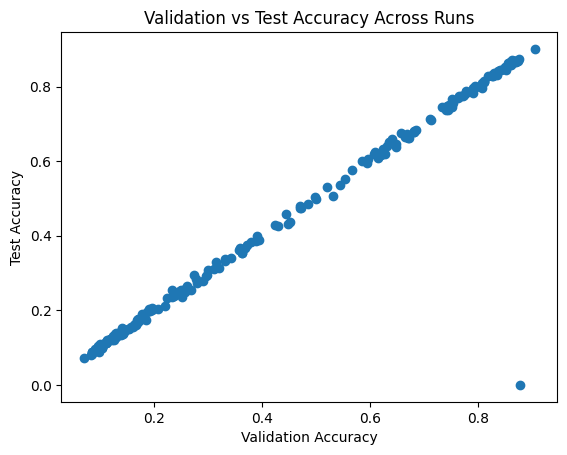

In [31]:
plt.scatter(val_acc, test_acc)
plt.xlabel('Validation Accuracy')
plt.ylabel('Test Accuracy')
plt.title('Validation vs Test Accuracy Across Runs')
plt.show()

## Error Analysis (Confusion Matrix)

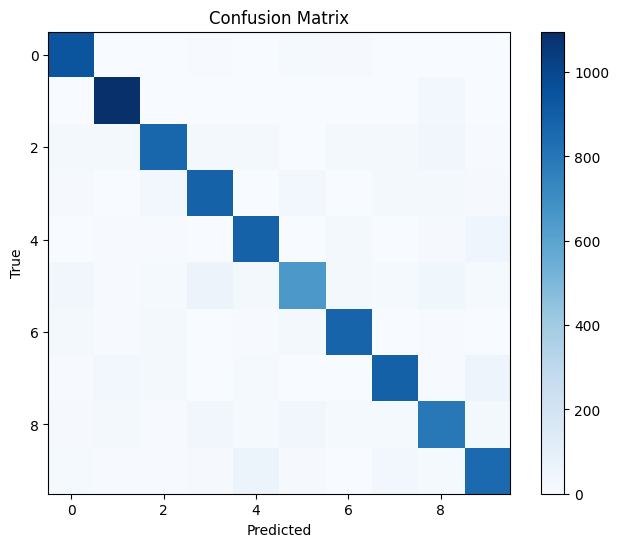

In [39]:
import sys
sys.path.append("../src")

import json
import numpy as np
import matplotlib.pyplot as plt
import wandb
from types import SimpleNamespace

from tensorflow.keras.datasets import mnist
from ann.neural_network import NeuralNetwork

wandb.init(project=PROJECT, name="confusion_matrix")

(_, _), (X_test, y_test) = mnist.load_data()

X_test = X_test.reshape(-1,784) / 255

with open("../src/best_config.json") as f:
    config = json.load(f)

cli_args = SimpleNamespace(**config)
model = NeuralNetwork(cli_args)

weights = np.load("../src/best_model.npy", allow_pickle=True).item()
model.set_weights(weights)

logits = model.forward(X_test)
preds = np.argmax(logits, axis=1)

cm = np.zeros((10,10))

for i in range(len(y_test)):
    cm[y_test[i]][preds[i]] += 1

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

wandb.log({"confusion_matrix": wandb.Image(plt)})
wandb.finish()

## Weight Initialization

In [40]:

cmd = [
    'python','../src/train.py',
    '--dataset','mnist',
    '--epochs','5',
    '--batch_size','64',
    '--optimizer','sgd',
    '--learning_rate','0.01',
    '--activation','tanh',
    '--hidden_size','128','128',
    '--weight_init','random',
    '--wandb_project',PROJECT,
    '--model_save_path','temp_model'
]

subprocess.run(cmd)


cmd = [
    'python','../src/train.py',
    '--dataset','mnist',
    '--epochs','5',
    '--batch_size','64',
    '--optimizer','sgd',
    '--learning_rate','0.01',
    '--activation','tanh',
    '--hidden_size','128','128',
    '--weight_init','xavier',
    '--wandb_project',PROJECT,
    '--model_save_path','temp_model'
]

subprocess.run(cmd)

I0000 00:00:1772983035.681280  896692 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772983035.686322  896692 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772983036.054071  896692 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772983039.940205  896692 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 2.3053 - Val Accuracy: 0.1115
Epoch 2/5 - Loss: 2.3052 - Val Accuracy: 0.1117
Epoch 3/5 - Loss: 2.3051 - Val Accuracy: 0.1118
Epoch 4/5 - Loss: 2.3050 - Val Accuracy: 0.1118
Epoch 5/5 - Loss: 2.3049 - Val Accuracy: 0.1118
Evaluating model...
Test Accuracy: 0.1135
Saving model...
Training complete.


I0000 00:00:1772983075.414660  896836 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772983075.416155  896836 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772983075.529326  896836 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772983077.258927  896836 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 2.2596 - Val Accuracy: 0.2252
Epoch 2/5 - Loss: 2.0705 - Val Accuracy: 0.4142
Epoch 3/5 - Loss: 1.9067 - Val Accuracy: 0.5502
Epoch 4/5 - Loss: 1.7623 - Val Accuracy: 0.6193
Epoch 5/5 - Loss: 1.6346 - Val Accuracy: 0.6580
Evaluating model...
Test Accuracy: 0.6496
Saving model...
Training complete.


CompletedProcess(args=['python', '../src/train.py', '--dataset', 'mnist', '--epochs', '5', '--batch_size', '64', '--optimizer', 'sgd', '--learning_rate', '0.01', '--activation', 'tanh', '--hidden_size', '128', '128', '--weight_init', 'xavier', '--wandb_project', 'da6401_mlp', '--model_save_path', 'temp_model'], returncode=0)

## Fashion-MNIST Transfer Experiments

In [32]:
configs = [
    ('rmsprop','relu',['128','128']),
    ('nag','relu',['128','64']),
    ('momentum','tanh',['128','128'])
]

for opt, act, layer in configs:

    cmd = [
        'python','../src/train.py',
        '--dataset','fashion_mnist',
        '--epochs','5',
        '--optimizer',opt,
        '--activation',act,
        '--hidden_size',*layer,
        '--wandb_project',PROJECT,
        '--model_save_path','temp_model'
    ]

    subprocess.run(cmd)

I0000 00:00:1772979274.659476  885047 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772979274.660098  885047 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772979274.711850  885047 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772979275.913321  885047 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 1.3525 - Val Accuracy: 0.7035
Epoch 2/5 - Loss: 0.7963 - Val Accuracy: 0.7605
Epoch 3/5 - Loss: 0.6800 - Val Accuracy: 0.7853
Epoch 4/5 - Loss: 0.6165 - Val Accuracy: 0.8002
Epoch 5/5 - Loss: 0.5741 - Val Accuracy: 0.8140
Evaluating model...
Test Accuracy: 0.8003
Saving model...
Training complete.


I0000 00:00:1772979294.513692  885133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772979294.514292  885133 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772979294.571269  885133 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772979295.861171  885133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 1.3813 - Val Accuracy: 0.7172
Epoch 2/5 - Loss: 0.7920 - Val Accuracy: 0.7762
Epoch 3/5 - Loss: 0.6624 - Val Accuracy: 0.7942
Epoch 4/5 - Loss: 0.5982 - Val Accuracy: 0.8147
Epoch 5/5 - Loss: 0.5591 - Val Accuracy: 0.8217
Evaluating model...
Test Accuracy: 0.8056
Saving model...
Training complete.


I0000 00:00:1772979316.963874  885255 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772979316.964616  885255 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772979317.009042  885255 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772979318.353510  885255 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Loading dataset...
Creating model...
Starting training...
Epoch 1/5 - Loss: 1.1739 - Val Accuracy: 0.7315
Epoch 2/5 - Loss: 0.7424 - Val Accuracy: 0.7777
Epoch 3/5 - Loss: 0.6413 - Val Accuracy: 0.7983
Epoch 4/5 - Loss: 0.5872 - Val Accuracy: 0.8108
Epoch 5/5 - Loss: 0.5527 - Val Accuracy: 0.8205
Evaluating model...
Test Accuracy: 0.804
Saving model...
Training complete.
